# Regression Using StatsModels
- Run a regression to find beta and alpha of FB to SPY
- FB<sub>t</sub> ~ $\beta$ * SPY<sub>t</sub> + $\alpha$ + e<sub>t</sub>

In [1]:
import statsmodels.api as sm
import pandas as pd
import numpy as np
import yfinance as yf 

# pip install yfinance
# https://pypi.org/project/yfinance/

In [11]:
# download price data
univ = ['SPY','META']
px = yf.download(univ, start="2016-01-01", end="2026-03-03")['Close']

[*********************100%***********************]  2 of 2 completed


In [12]:
px

Ticker,META,SPY
Date,,
2016-01-04,101.510910,170.372147
2016-01-05,102.017395,170.660294
2016-01-06,102.255722,168.507584
2016-01-07,97.240746,164.464844
2016-01-08,96.654831,162.659592
...,...,...
2026-02-24,639.299988,687.349976
2026-02-25,653.690002,693.150024
2026-02-26,657.010010,689.299988


In [13]:
# get returns
ret = px / px.shift() - 1
ret

Ticker,META,SPY
Date,,
2016-01-04,NaN,NaN
2016-01-05,0.004989,0.001691
2016-01-06,0.002336,-0.012614
2016-01-07,-0.049043,-0.023991
2016-01-08,-0.006025,-0.010977
...,...,...
2026-02-24,0.003217,0.007269
2026-02-25,0.022509,0.008438
2026-02-26,0.005079,-0.005554


In [14]:
# set X and Y. Have to add constant
X = ret[['SPY']]
X = sm.add_constant(X)

Y = ret['META']

In [15]:
# observe x,y
print (X)
print (Y)

            const       SPY
Date                       
2016-01-04    1.0       NaN
2016-01-05    1.0  0.001691
2016-01-06    1.0 -0.012614
2016-01-07    1.0 -0.023991
2016-01-08    1.0 -0.010977
...           ...       ...
2026-02-24    1.0  0.007269
2026-02-25    1.0  0.008438
2026-02-26    1.0 -0.005554
2026-02-27    1.0 -0.004802
2026-03-02    1.0  0.000569

[2554 rows x 2 columns]
Date
2016-01-04         NaN
2016-01-05    0.004989
2016-01-06    0.002336
2016-01-07   -0.049043
2016-01-08   -0.006025
                ...   
2026-02-24    0.003217
2026-02-25    0.022509
2026-02-26    0.005079
2026-02-27   -0.013440
2026-03-02    0.008300
Name: META, Length: 2554, dtype: float64


In [16]:
# can't do this - missing data
results = sm.OLS(Y, X).fit()

MissingDataError: exog contains inf or nans

In [17]:
# drop data
X = X.dropna()
Y = Y.dropna()
results = sm.OLS(Y, X).fit()

In [18]:
# check summary
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                   META   R-squared:                       0.373
Model:                            OLS   Adj. R-squared:                  0.373
Method:                 Least Squares   F-statistic:                     1519.
Date:                Mon, 09 Mar 2026   Prob (F-statistic):          4.62e-261
Time:                        07:21:02   Log-Likelihood:                 6467.8
No. Observations:                2553   AIC:                        -1.293e+04
Df Residuals:                    2551   BIC:                        -1.292e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0002      0.000      0.594      0.5

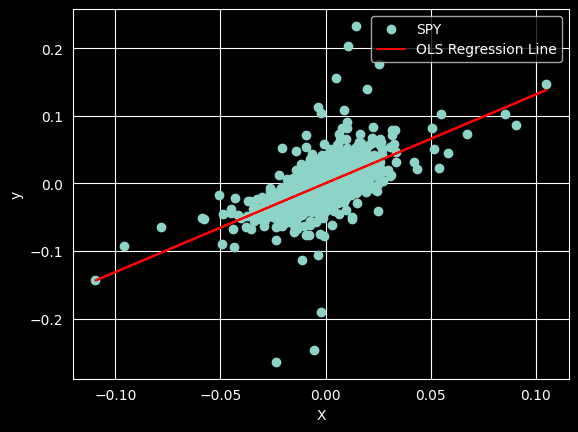

In [19]:
import matplotlib.pyplot as plt
plt.scatter(X.iloc[:, 1], Y, label='SPY')
plt.plot(X.iloc[:, 1], results.predict(X), color='red', label='OLS Regression Line')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()


In [20]:
X.iloc[:, 1]

Date
2016-01-05    0.001691
2016-01-06   -0.012614
2016-01-07   -0.023991
2016-01-08   -0.010977
2016-01-11    0.000990
                ...   
2026-02-24    0.007269
2026-02-25    0.008438
2026-02-26   -0.005554
2026-02-27   -0.004802
2026-03-02    0.000569
Name: SPY, Length: 2553, dtype: float64

In [21]:
# get params
results.params

const    0.000226
SPY      1.313035
dtype: float64

In [22]:
# get tvalues
results.tvalues

const     0.593584
SPY      38.971434
dtype: float64

Reconstruct FB
- FB<sub>t</sub> ~ $\beta$ * SPY<sub>t</sub> + $\alpha$ + e<sub>t</sub>

In [23]:
FB = results.params['SPY']*X['SPY'] + results.params['const'] + results.resid

In [24]:
# basically identical
(FB-Y).abs().sum()

np.float64(1.8285069638968032e-16)

In [25]:
FB-Y

Date
2016-01-05    0.0
2016-01-06    0.0
2016-01-07    0.0
2016-01-08    0.0
2016-01-11    0.0
             ... 
2026-02-24    0.0
2026-02-25    0.0
2026-02-26    0.0
2026-02-27    0.0
2026-03-02    0.0
Length: 2553, dtype: float64

In [26]:
beta_contr = results.params['SPY']*X['SPY']
prediction = results.params['SPY']*X['SPY'] + results.params['const']
alpha_contr = results.params['const'] + results.resid

In [27]:
alpha_contr

Date
2016-01-05    0.002769
2016-01-06    0.018899
2016-01-07   -0.017542
2016-01-08    0.008387
2016-01-11    0.000550
                ...   
2026-02-24   -0.006327
2026-02-25    0.011429
2026-02-26    0.012372
2026-02-27   -0.007135
2026-03-02    0.007554
Length: 2553, dtype: float64

<Axes: xlabel='Date'>

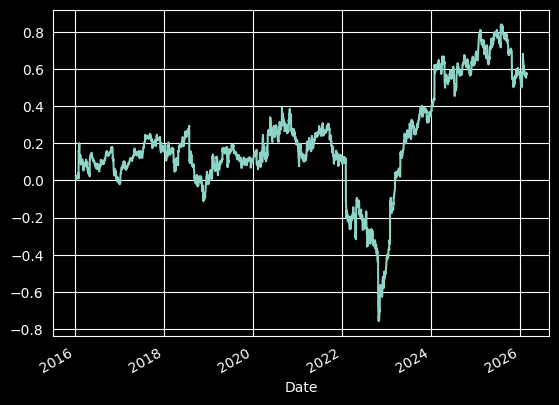

In [28]:
alpha_contr.cumsum().plot()

In [29]:
# correl is zero to spy
alpha_contr.corr(X['SPY'])

np.float64(-7.206969556719545e-16)

In [30]:
# "alpha"
alpha_contr.mean()

np.float64(0.00022608933090218354)

In [31]:
# information ratio
alpha_contr.mean()/alpha_contr.std()*np.sqrt(252)

np.float64(0.18679933748292318)

In [32]:
# alpha t-stat
results.tvalues['const']

np.float64(0.5935844340380354)